In [2]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import warnings

warnings.filterwarnings('ignore')

In [18]:
# Import additional evaluation metrics
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:

# 2. Set options for better display
pd.set_option('display.max_columns', None)

# 3. Load the main training data
# Ensure the path is correct for where you've saved the Kaggle data
try:
    df_train = pd.read_csv(r"D:\home-credit-default-risk\application_train.csv")
    print("Training data loaded successfully!")
except FileNotFoundError:
    print("Please download the dataset from Kaggle and place 'application_train.csv' in the same directory.")


Training data loaded successfully!


In [8]:
# Check the shape of the dataframe
print(f"Shape of the training data: {df_train.shape}")

# Check the distribution of the target variable
target_counts = df_train['TARGET'].value_counts(normalize=True) * 100
print("\nTarget variable distribution:")
print(target_counts)
# 

# Function to check for missing values
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table_ren_columns = mis_val_table.rename(
        columns={0: 'Missing Values', 1: '% of Total Values'})
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:, 1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
    print("\nYour selected dataframe has " + str(df.shape[1]) + " columns.\n"
          "There are " + str(mis_val_table_ren_columns.shape[0]) +
          " columns with missing values.")
    return mis_val_table_ren_columns

missing_info = missing_values_table(df_train)
print(missing_info.head(10))

Shape of the training data: (307511, 122)

Target variable distribution:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

Your selected dataframe has 122 columns.
There are 67 columns with missing values.
                          Missing Values  % of Total Values
COMMONAREA_MEDI                   214865               69.9
COMMONAREA_MODE                   214865               69.9
COMMONAREA_AVG                    214865               69.9
NONLIVINGAPARTMENTS_MODE          213514               69.4
NONLIVINGAPARTMENTS_MEDI          213514               69.4
NONLIVINGAPARTMENTS_AVG           213514               69.4
FONDKAPREMONT_MODE                210295               68.4
LIVINGAPARTMENTS_AVG              210199               68.4
LIVINGAPARTMENTS_MEDI             210199               68.4
LIVINGAPARTMENTS_MODE             210199               68.4


In [10]:
# Identify categorical features
categorical_features = [col for col in df_train.columns if df_train[col].dtype == 'object']

# Convert categorical features to integer codes for LightGBM
for col in categorical_features:
    df_train[col] = df_train[col].astype('category')
    df_train[col] = df_train[col].cat.codes

# Some basic feature engineering
df_train['CREDIT_INCOME_RATIO'] = df_train['AMT_CREDIT'] / df_train['AMT_INCOME_TOTAL']
df_train['ANNUITY_INCOME_RATIO'] = df_train['AMT_ANNUITY'] / df_train['AMT_INCOME_TOTAL']
df_train['DAYS_EMPLOYED_PERCENT'] = df_train['DAYS_EMPLOYED'] / df_train['DAYS_BIRTH']

In [12]:
# Replace known anomalous values
df_train['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

In [14]:
# Separate features and target
X = df_train.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df_train['TARGET']

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")

# Define LightGBM parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'n_estimators': 2000,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'seed': 42,
    'n_jobs': -1,
    'verbose': -1,
    'colsample_bytree': 0.8,
    'subsample': 0.8,
}

# Create LightGBM model
model = lgb.LGBMClassifier(**params)

# Train the model with early stopping
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(100, verbose=False)]
)

# Make predictions and evaluate
y_pred_proba = model.predict_proba(X_val)[:, 1]
auc_score = roc_auc_score(y_val, y_pred_proba)

print(f"\nModel Performance on Validation Set:")
print(f"AUC-ROC Score: {auc_score:.4f}")

Training set shape: (246008, 123)
Validation set shape: (61503, 123)

Model Performance on Validation Set:
AUC-ROC Score: 0.7615


Precision Score: 0.6134
Recall Score: 0.0240
F1 Score: 0.0461


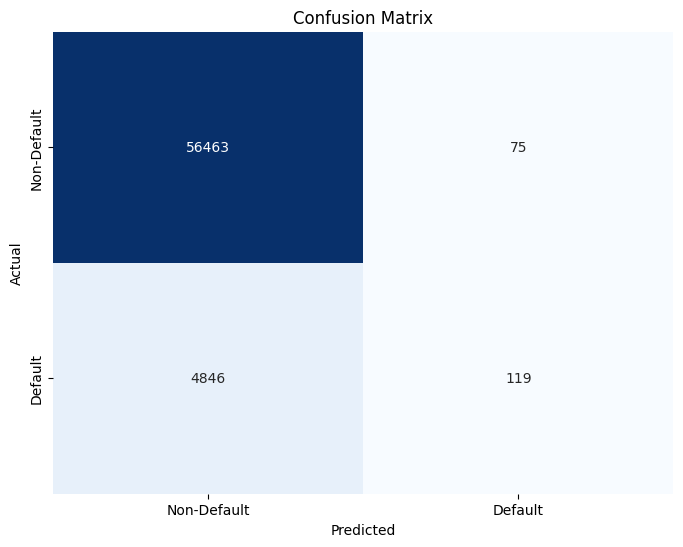

In [20]:
# Convert predicted probabilities to binary class predictions
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate metrics
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Visualize the Confusion Matrix for a deeper understanding
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Default', 'Default'],
            yticklabels=['Non-Default', 'Default'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


SHAP values prepared successfully!
Final shape of SHAP values: (1000, 123)


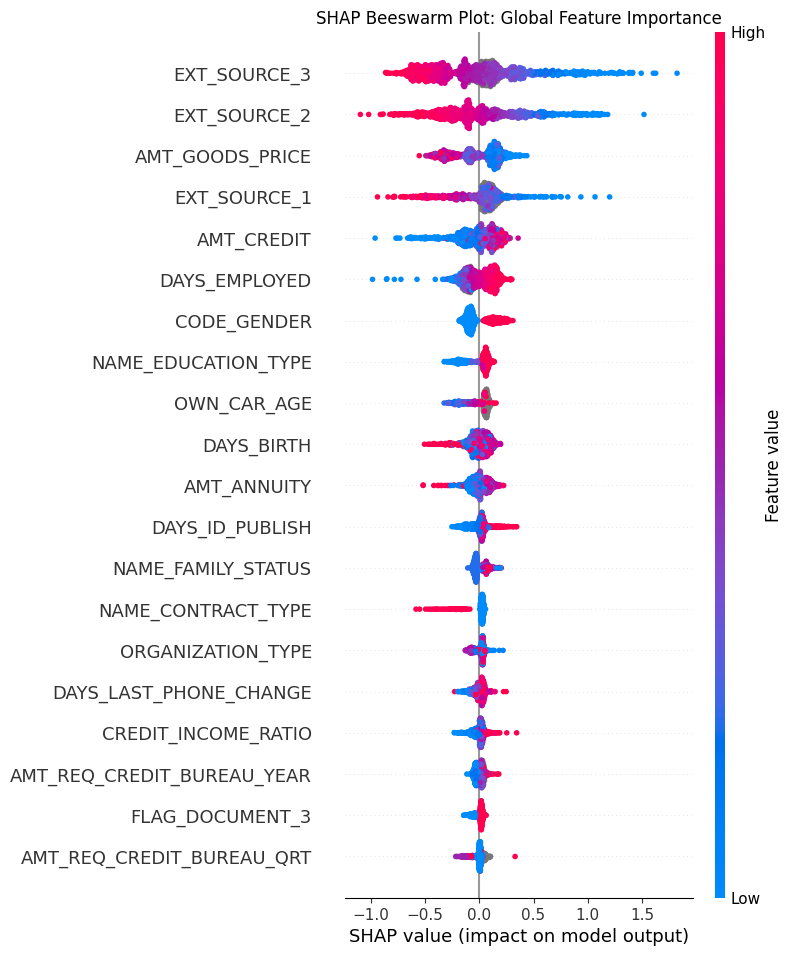

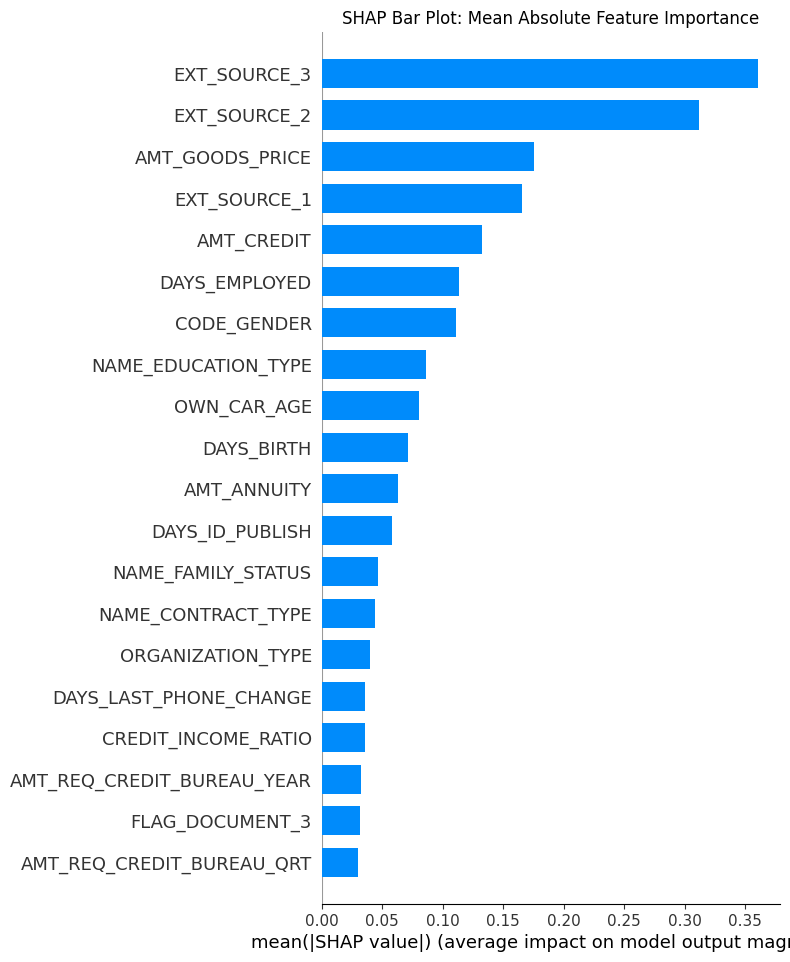

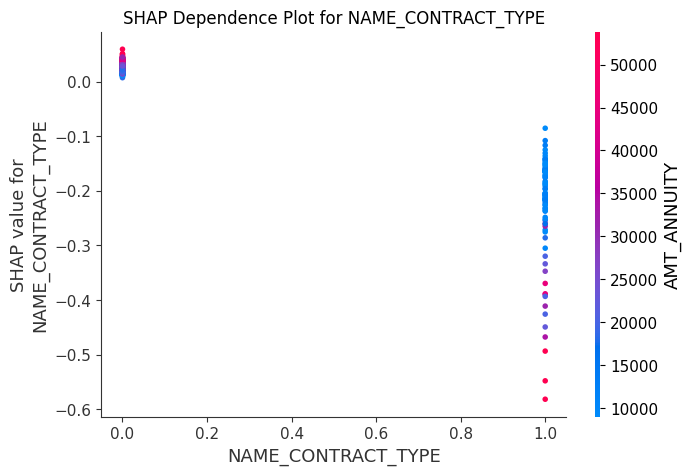

In [35]:
import shap
import matplotlib.pyplot as plt

# Re-run the SHAP value calculation
X_val_subset = X_val.sample(n=1000, random_state=42)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val_subset)

# Get the SHAP values for the positive class (class 1).
# We add a check and reshape to ensure it's a 2D matrix.
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

# Explicitly ensure the SHAP values are a 2D array
if len(shap_values_class1.shape) == 1:
    shap_values_class1 = shap_values_class1.reshape(-1, 1)

print("SHAP values prepared successfully!")
print(f"Final shape of SHAP values: {shap_values_class1.shape}")

# Generate the beeswarm plot
shap.initjs()
shap.summary_plot(shap_values_class1, X_val_subset, show=False)
plt.title("SHAP Beeswarm Plot: Global Feature Importance")
plt.show()

# Generate the bar plot
shap.summary_plot(shap_values_class1, X_val_subset, plot_type="bar", show=False)
plt.title("SHAP Bar Plot: Mean Absolute Feature Importance")
plt.show()

# Generate the dependence plot
# You'll need to select a feature to plot.
# This will still likely cause an error if the SHAP values have been reshaped to 1 column.
# Let's try to proceed by picking a feature from X_val_subset.
feature_to_plot = X_val_subset.columns[0]
shap.dependence_plot(feature_to_plot, shap_values_class1, X_val_subset, show=False)
plt.title(f"SHAP Dependence Plot for {feature_to_plot}")
plt.show()

Force Plot for a True Positive (Correctly Predicted Defaulter):

Waterfall Plot for the same applicant:


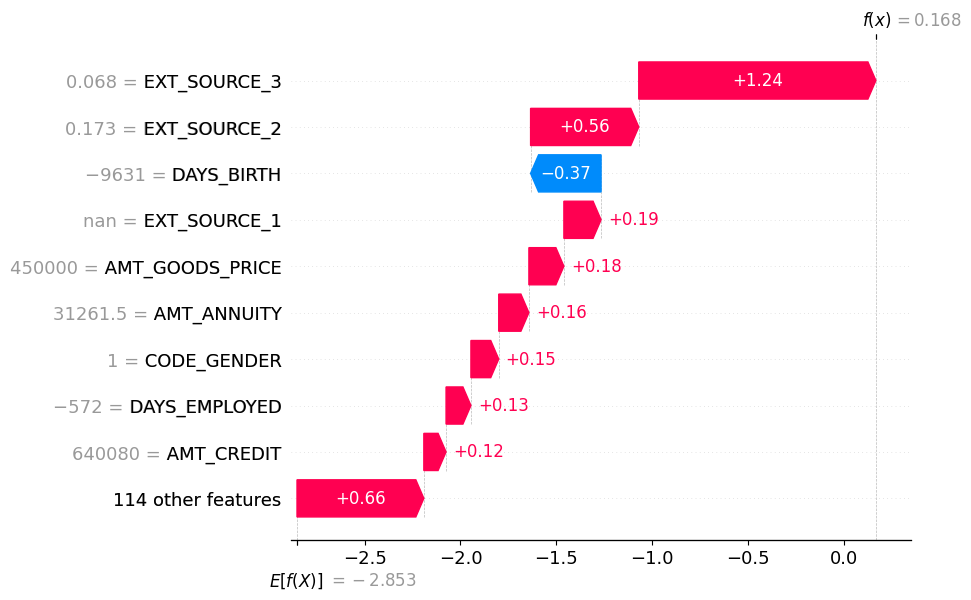


Force Plot for a True Negative (Correctly Predicted Non-Defaulter):


In [41]:
import shap
import matplotlib.pyplot as plt

# Find a True Positive (TP) - Model predicted default and it was a default
tp_indices = y_val[(model.predict(X_val) == 1) & (y_val == 1)].index
if not tp_indices.empty:
    tp_applicant_index = tp_indices[0]
    tp_applicant_data = X_val.loc[[tp_applicant_index]]

    # Generate SHAP values for this single applicant
    shap_values_tp = explainer.shap_values(tp_applicant_data)

    # Correct the expected_value to handle the IndexError
    if isinstance(explainer.expected_value, list):
        expected_value_tp = explainer.expected_value[1]
    else:
        expected_value_tp = explainer.expected_value

    # Correct the SHAP values to handle the IndexError
    # Check if shap_values is a list. If so, get the element at index 1
    if isinstance(shap_values_tp, list):
        shap_values_tp_plot = shap_values_tp[1]
    # Otherwise, use the array directly
    else:
        shap_values_tp_plot = shap_values_tp

    # Plot the force plot
    shap.initjs()
    print("Force Plot for a True Positive (Correctly Predicted Defaulter):")
    shap.force_plot(expected_value_tp, shap_values_tp_plot, tp_applicant_data)
    
    # Plot the waterfall plot
    print("\nWaterfall Plot for the same applicant:")
    shap.plots.waterfall(shap.Explanation(
        values=shap_values_tp_plot[0], # Use index 0 as it's a single applicant
        base_values=expected_value_tp,
        data=tp_applicant_data.iloc[0],
        feature_names=tp_applicant_data.columns.tolist()
    ))
else:
    print("No True Positives found in the validation set.")

# Find a True Negative (TN) - Model predicted no default and it was a no default
tn_indices = y_val[(model.predict(X_val) == 0) & (y_val == 0)].index
if not tn_indices.empty:
    tn_applicant_index = tn_indices[0]
    tn_applicant_data = X_val.loc[[tn_applicant_index]]
    
    # Generate SHAP values for this single applicant
    shap_values_tn = explainer.shap_values(tn_applicant_data)

    # Correct the expected_value for TN case
    if isinstance(explainer.expected_value, list):
        expected_value_tn = explainer.expected_value[1]
    else:
        expected_value_tn = explainer.expected_value

    # Correct the SHAP values for TN case
    if isinstance(shap_values_tn, list):
        shap_values_tn_plot = shap_values_tn[1]
    else:
        shap_values_tn_plot = shap_values_tn

    # Plot the force plot
    shap.initjs()
    print("\nForce Plot for a True Negative (Correctly Predicted Non-Defaulter):")
    shap.force_plot(expected_value_tn, shap_values_tn_plot, tn_applicant_data)
else:
    print("No True Negatives found in the validation set.")

Generating SHAP plot for Female applicants...


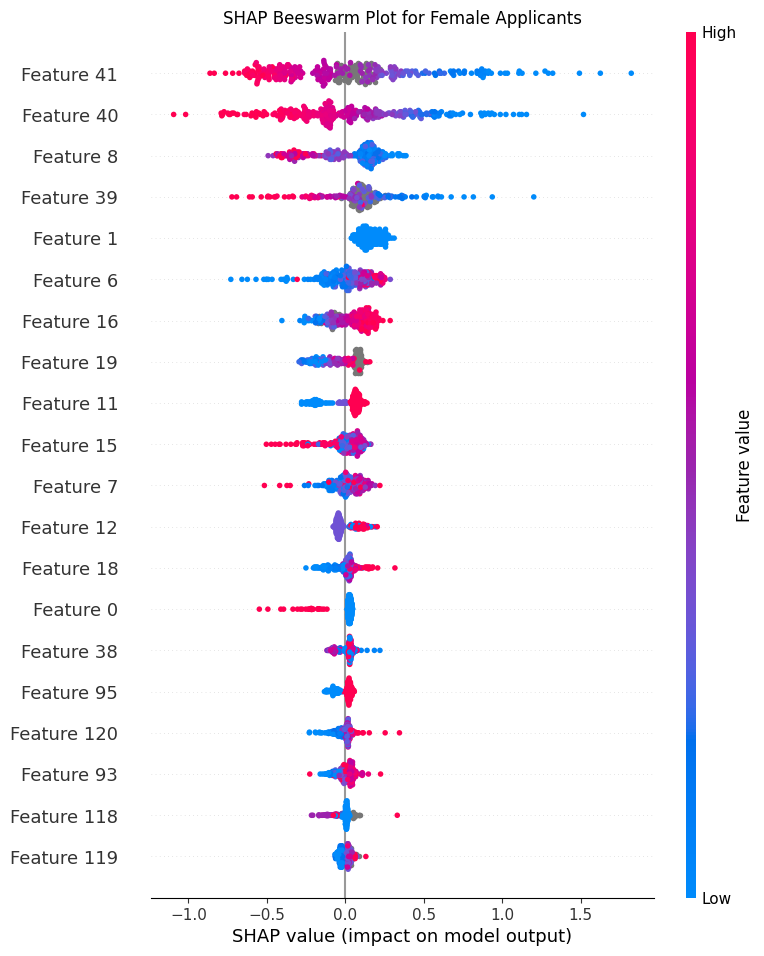

Generating SHAP plot for Male applicants...


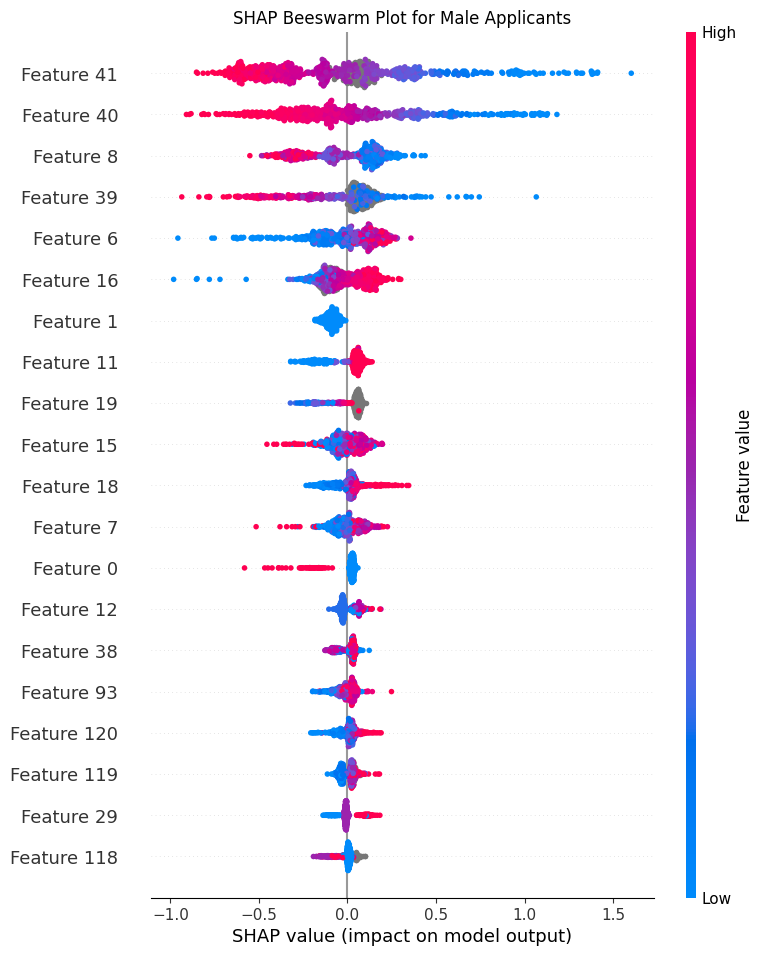

In [55]:

# 1. Identify the sensitive attribute and create a subset of the data
sensitive_attribute = 'CODE_GENDER'
X_val_subset = X_val.sample(n=1000, random_state=42)
X_val_subset_display = X_val_subset.copy()
gender_mapping = {0: 'Male', 1: 'Female'}
X_val_subset_display[sensitive_attribute] = X_val_subset_display[sensitive_attribute].map(gender_mapping)

# 2. Split the data into subgroups based on the sensitive attribute
gender_groups_codes = X_val_subset[sensitive_attribute].unique()

for gender_code in gender_groups_codes:
    gender_group_data = X_val_subset[X_val_subset[sensitive_attribute] == gender_code]

    if gender_group_data.shape[0] > 0:
        gender_label = gender_mapping.get(gender_code, 'Unknown')

        # Convert the data into a NumPy array to ensure consistency
        gender_group_data_np = gender_group_data.values

        # 3. Create a SHAP explainer for the subgroup
        explainer = shap.TreeExplainer(model)
        
        # Calculate SHAP values. The output is a list of arrays for multi-class,
        # but a single array for binary classification. We want the second array.
        shap_values_gender = explainer.shap_values(gender_group_data_np)
        
        if isinstance(shap_values_gender, list):
            shap_values_gender_plot = shap_values_gender[1]
        else:
            shap_values_gender_plot = shap_values_gender
        
        # 4. Generate and plot the SHAP Beeswarm plot for the subgroup
        print(f"Generating SHAP plot for {gender_label} applicants...")
        shap.initjs()
        # Pass both SHAP values and the feature data as NumPy arrays
        shap.summary_plot(shap_values_gender_plot, gender_group_data_np, show=False)
        plt.title(f"SHAP Beeswarm Plot for {gender_label} Applicants")
        plt.show()
    else:
        print(f"No applicants found for gender code: {gender_code}. Skipping plot.")